### Tool Use
- Agents can call external tools (functions) to retrieve information or perform actions
- The LLM decides which tool to call and with what arguments
- LangGraph manages the loop: LLM → Tool Call → Result → LLM (until no more tool calls)

In [8]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage
import operator
from typing import TypedDict, List, Annotated
from langgraph.graph.message import AnyMessage

load_dotenv()

True

In [9]:
# Define tools the agent can use
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    # Simulated weather data
    weather_data = {
        "paris": "15°C, partly cloudy",
        "london": "12°C, rainy",
        "tokyo": "22°C, sunny",
        "new york": "18°C, clear skies",
    }
    return weather_data.get(city.lower(), f"No weather data available for {city}")


@tool
def calculate_tip(bill_amount: float, tip_percentage: float) -> str:
    """Calculate the tip amount given a bill total and tip percentage."""
    tip = bill_amount * (tip_percentage / 100)
    total = bill_amount + tip
    return f"Tip: ${tip:.2f}, Total: ${total:.2f}"

In [10]:
# Bind tools to the model
tools = [get_weather, calculate_tip]
tool_map = {t.name: t for t in tools}

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
model_with_tools = model.bind_tools(tools)

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], operator.add]

In [13]:
# Node 1: Call the LLM (may produce tool calls or a final answer)
def call_model(state: AgentState) -> AgentState:
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [14]:
# Node 2: Execute the requested tools and return results
def call_tools(state: AgentState) -> AgentState:
    last_message = state["messages"][-1]
    tool_messages = []
    for tool_call in last_message.tool_calls:
        tool_fn = tool_map[tool_call["name"]]
        result = tool_fn.invoke(tool_call["args"])
        tool_messages.append(
            ToolMessage(content=str(result), tool_call_id=tool_call["id"])
        )
        print(f"Tool called: {tool_call['name']}({tool_call['args']}) -> {result}")
    return {"messages": tool_messages}

In [16]:
# Router: decide whether to call tools or finish
def should_call_tools(state: AgentState) -> str:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "call_tools"
    return END

In [17]:
# Build the graph
workflow = StateGraph(AgentState)

workflow.add_node("call_model", call_model)
workflow.add_node("call_tools", call_tools)

workflow.set_entry_point("call_model")
workflow.add_conditional_edges(
    "call_model", 
    should_call_tools, 
    {
        "call_tools": "call_tools", 
        END: END
    }
)
workflow.add_edge("call_tools", "call_model")

graph = workflow.compile()

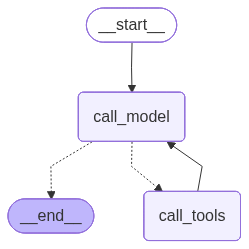

In [7]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

graph_image = graph.get_graph().draw_mermaid_png(
    draw_method=MermaidDrawMethod.API
)

display(Image(graph_image))

In [22]:
# Test 1: Single tool call
print("---- Test 1: Weather Query ----")
result = graph.invoke({"messages": [("user", "What's the weather like in Tokyo?")]})
for msg in result["messages"]:
    print(msg)
print("Response:", result["messages"][-1].content)

---- Test 1: Weather Query ----
Tool called: get_weather({'city': 'Tokyo'}) -> 22°C, sunny
('user', "What's the weather like in Tokyo?")
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 85, 'total_tokens': 99, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D4aECNPAtiP5tWtm6fnVEwFz79CzT', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019c1b52-ebf0-7bc1-98bc-8a310757eada-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'call_67MEg0dvB5ljhSfcau1Zo0Uz', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 85, 'output_tokens': 14, 'total_tokens': 99, 'in

In [23]:
# Test 2: Tool call with follow-up reasoning
print("---- Test 2: Tip Calculator ----")
result = graph.invoke({
    "messages": [("user", "My dinner bill is $85.50. What would a 20% tip be?")]
})
print("Response:", result["messages"][-1].content)

---- Test 2: Tip Calculator ----
Tool called: calculate_tip({'bill_amount': 85.5, 'tip_percentage': 20}) -> Tip: $17.10, Total: $102.60
Response: A 20% tip on your dinner bill of $85.50 would be $17.10. The total amount including the tip would be $102.60.


In [ ]:
# Test 3: Multi-tool call in a single query
print("---- Test 3: Tip + Weather ----")
result = graph.invoke({
    "messages": [("user", "I'm visiting London. What's the weather and what would be a 12% tip on a $45 bill?")]
})
for msg in result["messages"]:
    print(msg)
print("Response:", result["messages"][-1].content)

---- Test 3: Restaurant + Weather ----
Tool called: get_weather({'city': 'London'}) -> 12°C, rainy
Tool called: calculate_tip({'bill_amount': 45, 'tip_percentage': 12}) -> Tip: $5.40, Total: $50.40
('user', "I'm visiting London. What's the weather and what would be a 12% tip on a $45 bill?")
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 100, 'total_tokens': 150, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D4aFhgQVwocZoxWqGEWGGVj4qedq3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019c1b54-588a-7ef2-aa48-6c9af0a337ed-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'London'}, 'id'

In [26]:
# Test 4: No tool needed - direct answer
print("---- Test 4: No Tool Needed ----")
result = graph.invoke({
    "messages": [("user", "I dont know what to ask.")]
})
print("Response:", result["messages"][-1].content)

---- Test 4: No Tool Needed ----
Response: That's okay! Here are a few ideas you might find interesting:

1. **Weather Information**: Ask about the current weather in a specific city.
2. **Travel Tips**: Inquire about travel destinations or tips for your next trip.
3. **Food and Recipes**: Ask for recipe ideas or cooking tips.
4. **Health and Fitness**: Get advice on exercise routines or healthy eating.
5. **Technology**: Ask about the latest tech trends or gadgets.
6. **Finance**: Inquire about budgeting tips or investment advice.
7. **Fun Facts**: Request interesting facts about a topic you like.

Feel free to pick one of these or let me know if you have something else in mind!
